<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        background-color:#38bdf8;
        color:black;
        padding:10px 26px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     ASL Project – Notebook 2: Detection & Real-Time Recognition
  </span>
</div>


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:17px;">

  <p>
    In the <b>first notebook</b>, we successfully built a powerful
    <b>ASL hand sign classification model</b> that was able to recognize
    the hand gesture <b>only after the image was already cropped and prepared</b>.
  </p>

  <p>
    However, this creates a <b>real-world limitation</b>:
  </p>

  <ul>
    <li>When we open the <b>camera</b>, the model <b>does not know where the hand is located</b> in the image.</li>
    <li>It can only classify an image if the hand is already <b>manually extracted</b>.</li>
  </ul>

  <p style="margin-top:12px;">
     <b>To solve this problem, we move to the next major step:</b>
  </p>

  <p>
    In this notebook, we will use a powerful <b>real-time object detection model called YOLOv8</b>.
  </p>

  <p>
    <b>YOLOv8 (You Only Look Once)</b> is a state-of-the-art deep learning model that is designed to:
  </p>

  <ul>
    <li> Detect objects <b>in real-time</b></li>
    <li> Locate objects using <b>bounding boxes</b></li>
    <li> Classify each detected object at the <b>same time</b></li>
    <li> Work at <b>high speed with high accuracy</b></li>
  </ul>

  <p style="margin-top:12px;">
    In our ASL project, <b>YOLOv8 will be responsible for:</b>
  </p>

  <ul>
    <li>Detecting the <b>hand location</b> automatically inside each camera frame</li>
    <li>Drawing a <b>bounding box</b> around the detected hand</li>
    <li>Classifying the detected hand into the correct <b>ASL letter (A–Z)</b></li>
    <li>Performing both <b>detection and classification simultaneously</b> in real-time</li>
  </ul>

  <p style="margin-top:12px;">
    This means that we will combine:
  </p>

  <div style="text-align:center; background-color:#020617; padding:12px; border-radius:10px; font-weight:bold; color:#38bdf8;">
     YOLOv8 Detection + ASL Classification = Real-Time ASL Recognition System
  </div>

  <p style="margin-top:12px;">
    By the end of this notebook, we will have a <b>complete real-time AI system</b> that can:
  </p>

  <ul>
    <li>Detect the hand from the <b>live camera feed</b></li>
    <li>Recognize the <b>ASL letter instantly</b></li>
    <li>Display the prediction with a <b>bounding box and confidence score</b></li>
    <li>Work as a true <b>AI Assistant for learning Sign Language</b></li>
  </ul>

  <p style="margin-top:12px;">
    This notebook represents the <b>practical deployment stage</b> of our ASL project,
    where the system becomes fully <b>interactive, real-time, and usable in real-world scenarios</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Environment Setup & Key Libraries for YOLOv8 Notebook
  </span>
</div>

In [1]:
###!pip install scikit-learn==1.2.2
###!pip install numpy==1.26.4
###!pip install scipy==1.10.1 matplotlib==3.7.2 albumentations ultralytics opencv-python


In [2]:
!pip install ultralytics


In [3]:
!pip install roboflow


In [4]:
import os, glob, shutil, random, json, yaml, time
from pathlib import Path
import numpy as np, cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from ultralytics import YOLO
from roboflow import Roboflow
import albumentations as A

SEED = 42
random.seed(SEED); np.random.seed(SEED)

WORK_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else os.getcwd()
PROJECT_DIR = os.path.join(WORK_DIR, "SignLang_YOLO_pipeline")
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project dir:", PROJECT_DIR)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Project dir: /kaggle/working/SignLang_YOLO_pipeline


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    This cell installs and imports the <b>essential packages</b> and performs the initial project setup required
    to run <b>YOLOv8-based detection + classification</b> pipelines on Kaggle (or a local machine).
  </p>

  <p style="margin-top:10px;"><b>Packages installed (via pip) and their roles:</b></p>

  <ul>
    <li><b>scikit-learn (1.2.2)</b> → Utility functions, metrics, and dataset helpers (train/test utilities & evaluation).</li>
    <li><b>numpy (1.26.4)</b> → Core numerical operations and array handling.</li>
    <li><b>scipy (1.10.1)</b> → Scientific utilities (used occasionally for image/array ops).</li>
    <li><b>matplotlib (3.7.2)</b> & <b>seaborn</b> → Visualization of metrics, confusion matrices, and sample images.</li>
    <li><b>albumentations</b> → Fast, flexible image augmentation pipeline used for training robustness.</li>
    <li><b>ultralytics</b> → Official YOLOv8 library for model loading, training, and inference (object detection).</li>
    <li><b>opencv-python (cv2)</b> → Image I/O, preprocessing, and real-time camera access for inference.</li>
    <li><b>roboflow</b> → Handy utilities for loading/exporting datasets from Roboflow (optional convenience).</li>
    <li><b>tqdm</b> → Progress bars for loops (dataset preparation / conversion steps).</li>
  </ul>

  <p style="margin-top:10px;"><b>Python imports and their purpose:</b></p>

  <ul>
    <li><b>os, glob, shutil, random, json, yaml, time, pathlib.Path</b> → File system handling, dataset organization, reproducibility, and small utilities.</li>
    <li><b>numpy, cv2</b> → Image loading and array manipulation.</li>
    <li><b>matplotlib.pyplot, seaborn</b> → Visualization (plots, heatmaps, example images).</li>
    <li><b>tqdm</b> → Visual progress bars for long operations.</li>
    <li><b>ultralytics.YOLO</b> → Main class to load, train and run YOLOv8 models.</li>
    <li><b>roboflow.Roboflow</b> → (Optional) programmatic access to Roboflow datasets and exports.</li>
    <li><b>albumentations as A</b> → Define augmentation pipelines for detector training.</li>
  </ul>

  <p style="margin-top:10px;"><b>Project configuration explained:</b></p>

  <ul>
    <li><b>SEED = 42</b> → Fixes randomness for reproducible results (random, numpy, and other libs).</li>
    <li><b>WORK_DIR</b> → Uses Kaggle working directory if available, otherwise current working directory. Keeps outputs in a known place.</li>
    <li><b>PROJECT_DIR</b> → A dedicated folder (<code>SignLang_YOLO_pipeline</code>) where data conversions, exported datasets, model checkpoints and logs will be stored.</li>
    <li><b>os.makedirs(..., exist_ok=True)</b> → Ensures the project directory exists without errors.</li>
  </ul>

  <p style="margin-top:10px;">
    Together, these installations and imports prepare the environment to:
  </p>

  <ul>
    <li>Train and fine-tune <b>YOLOv8</b> object detectors.</li>
    <li>Apply <b>advanced augmentations</b> during detector training.</li>
    <li>Run <b>real-time inference</b> from a webcam or video stream using OpenCV + YOLOv8.</li>
    <li>Log, visualize, and evaluate results using plotting and sklearn utilities.</li>
  </ul>

  <p style="margin-top:12px;">
    This makes the notebook ready for the <b>detection + classification</b> workflow that follows.
  </p>

</div>

<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Downloading the Dataset from Roboflow
  </span>
</div>


In [5]:
ROBOFLOW_API_KEY = "ZGMgGBuM9g0mHRhJWNwr"   

WORKSPACE_NAME = "pbdiplomodv"
PROJECT_NAME = "sign_language-m2nvf"
VERSION_NUMBER = 2

print("Downloading dataset from Roboflow... (may take a minute)")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)
dataset = version.download("yolov8")

BASE_DATA = dataset.location if hasattr(dataset, "location") else str(dataset)
print("Base data path:", BASE_DATA)

for sub in ["train/images", "train/labels", "valid/images", "valid/labels", "test/images", "test/labels"]:
    p = os.path.join(BASE_DATA, sub)
    print(f" - {sub}: {'FOUND' if os.path.exists(p) and len(glob.glob(os.path.join(p,'*'))) > 0 else 'MISSING or EMPTY'}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sign_Language-2 in yolov8:: 100%|██████████| 6924/6924 [00:00<00:00, 10579.04it/s]

Base data path: /kaggle/working/Sign_Language-2
 - train/images: FOUND
 - train/labels: FOUND
 - valid/images: FOUND
 - valid/labels: FOUND
 - test/images: FOUND
 - test/labels: FOUND


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    In this step, we <b>download our ASL detection dataset directly from Roboflow</b>
    using the official Roboflow API.
  </p>

  <p>
    The dataset is automatically downloaded in a format that is fully compatible with
    <b>YOLOv8 object detection training</b>.
  </p>

  <p style="margin-top:12px;">
     <b>Dataset Link (Click to Open):</b>
  </p>

  <div style="background-color:#020617; padding:12px; border-radius:10px; text-align:center;">
    <a href="https://universe.roboflow.com/pbdiplomodv/sign_language-m2nvf/dataset/1" 
       target="_blank" 
       style="color:#38bdf8; font-weight:bold; font-size:16px; text-decoration:none;">
       🔗 https://universe.roboflow.com/pbdiplomodv/sign_language-m2nvf/dataset/1
    </a>
  </div>

  <p style="margin-top:12px;">
    Using the <b>Roboflow API</b>, we:
  </p>

  <ul>
    <li>Connect to the Roboflow workspace</li>
    <li>Select the correct project and dataset version</li>
    <li>Download the dataset in <b>YOLOv8 format</b></li>
    <li>Automatically organize it into:
      <ul>
        <li><b>train/images & train/labels</b></li>
        <li><b>valid/images & valid/labels</b></li>
        <li><b>test/images & test/labels</b></li>
      </ul>
    </li>
  </ul>

  <p style="margin-top:12px;">
    After downloading, we verify that all dataset folders exist and contain images and labels,
    ensuring that the data is <b>ready for YOLOv8 training and real-time detection</b>.
  </p>

  <p style="margin-top:12px;">
    This step guarantees that our detection pipeline is built on a
    <b>properly structured, annotated, and verified dataset</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Dataset Paths & Statistics (Before Augmentation)
  </span>
</div>


In [6]:
train_imgs = os.path.join(BASE_DATA, "train", "images")
train_lbls = os.path.join(BASE_DATA, "train", "labels")
val_imgs = os.path.join(BASE_DATA, "valid", "images")
val_lbls = os.path.join(BASE_DATA, "valid", "labels")
test_imgs = os.path.join(BASE_DATA, "test", "images")
test_lbls = os.path.join(BASE_DATA, "test", "labels")

yaml_path = os.path.join(BASE_DATA, "data.yaml")
orig_names = None
if os.path.exists(yaml_path):
    with open(yaml_path) as f:
        data_cfg = yaml.safe_load(f)
        orig_names = data_cfg.get("names", None)

def count_jpgs(path):
    return len(glob.glob(os.path.join(path, "*.jpg")))

print("== Before augmentation ==")
print("Train images:", count_jpgs(train_imgs))
print("Train label files:", len(glob.glob(os.path.join(train_lbls, "*.txt"))))
print("Valid images:", count_jpgs(val_imgs))
print("Test images:", count_jpgs(test_imgs))

if orig_names:
    with open(os.path.join(PROJECT_DIR, "orig_names.json"), "w") as f:
        json.dump(orig_names, f, indent=2)
    print("Saved orig_names.json")
else:
    print("No data.yaml names found or empty.")


== Before augmentation ==
Train images: 3024
Train label files: 3024
Valid images: 288
Test images: 144
Saved orig_names.json


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    In this step, we prepare the <b>absolute paths</b> for the dataset used in YOLOv8 training by
    defining the directories for:
  </p>

  <ul>
    <li><b>Training images & labels</b></li>
    <li><b>Validation images & labels</b></li>
    <li><b>Testing images & labels</b></li>
  </ul>

  <p style="margin-top:12px;">
    We also read the <b>data.yaml</b> file to extract the original
    <b>class names (labels)</b> used in the dataset.
  </p>

  <p>
    To preserve this information, we save the class list into a separate file:
  </p>

  <div style="background-color:#020617; padding:12px; border-radius:10px; font-family:monospace; color:#e5e7eb;">
    orig_names.json
  </div>

  <p style="margin-top:12px;">
     <b>Dataset Statistics Before Augmentation:</b>
  </p>

  <div style="background-color:#020617; padding:14px; border-radius:10px; font-family:monospace; font-size:15px; color:#e5e7eb;">
    Train Images: 3024<br>
    Train Label Files: 3024<br>
    Validation Images: 288<br>
    Test Images: 144
  </div>

  <p style="margin-top:12px;">
    These numbers confirm that:
  </p>

  <ul>
    <li>Each training image has a corresponding <b>YOLO label file</b></li>
    <li>The dataset is <b>properly split</b> into Train, Validation, and Test</li>
    <li>The data is now fully <b>ready for augmentation and YOLOv8 training</b></li>
  </ul>

  <p style="margin-top:12px;">
    This step serves as a <b>baseline verification</b> before we apply any
    <b>data augmentation or dataset balancing</b> techniques.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Visual Inspection of Training Samples 
  </span>
</div>


Sample train images (BEFORE augmentation):


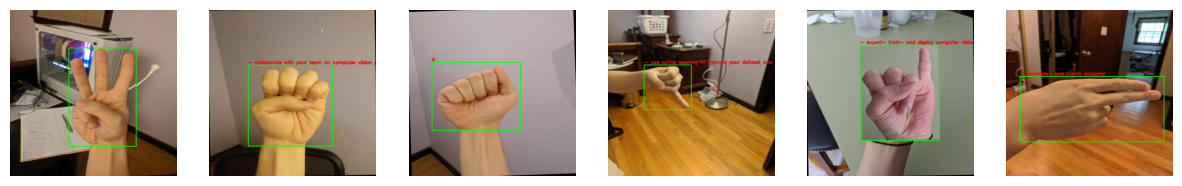

In [7]:
def read_yolo_txt(path):
    boxes=[]
    if not os.path.exists(path): return boxes
    with open(path) as f:
        for line in f:
            parts=line.strip().split()
            if len(parts)>=5:
                try:
                    cls=int(float(parts[0])); coords=list(map(float, parts[1:5]))
                    boxes.append((cls, coords))
                except:
                    continue
    return boxes

def show_samples(img_dir, lbl_dir, names, n=6, seed=SEED):
    imgs = sorted(glob.glob(os.path.join(img_dir,"*.jpg")))
    if len(imgs)==0:
        print("No images in", img_dir); return
    random.seed(seed)
    sel = random.sample(imgs, min(n, len(imgs)))
    plt.figure(figsize=(15,6))
    for i,p in enumerate(sel):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        h,w,_ = img.shape
        lbl = os.path.join(lbl_dir, os.path.basename(p).replace(".jpg",".txt"))
        if os.path.exists(lbl):
            for cls, box in read_yolo_txt(lbl):
                xc,yc,bw,bh = box
                x1=int((xc-bw/2)*w); y1=int((yc-bh/2)*h)
                x2=int((xc+bw/2)*w); y2=int((yc+bh/2)*h)
                cv2.rectangle(img, (x1,y1),(x2,y2),(0,255,0),2)
                name = names[cls] if names and cls < len(names) else str(cls)
                cv2.putText(img, name, (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        plt.subplot(1,len(sel),i+1); plt.imshow(img); plt.axis('off')
    plt.show()

print("Sample train images (BEFORE augmentation):")
show_samples(train_imgs, train_lbls, orig_names if orig_names else None, n=6)


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    In this step, we display a random set of <b>training images with their YOLO bounding boxes</b>
    in order to visually inspect the dataset <b>before starting augmentation and fine-tuning</b>.
  </p>

  <p>
    Each displayed image includes:
  </p>

  <ul>
    <li>The original <b>training image</b></li>
    <li>The <b>bounding box</b> drawn around the detected hand</li>
    <li>The corresponding <b>ASL class label</b> displayed on the image</li>
  </ul>

  <p style="margin-top:12px;">
     <b>Why this visualization step is critical:</b>
  </p>

  <ul>
    <li>To verify that <b>all images are loading correctly</b> without corruption</li>
    <li>To ensure that <b>bounding boxes are accurate</b> and correctly placed around the hand</li>
    <li>To confirm that <b>class labels match the hand gestures</b></li>
    <li>To detect any <b>annotation errors</b> such as misaligned boxes or wrong labels</li>
  </ul>

  <p style="margin-top:12px;">
     If any problems are detected at this stage (wrong boxes, missing labels, distorted images),
    they can be <b>fixed immediately before starting the fine-tuning process</b>.
  </p>

  <p style="margin-top:12px;">
    Performing this manual inspection step ensures that the model will be trained on
    <b>clean, accurate, and high-quality data</b>,
    which is essential for achieving <b>high real-time detection accuracy with YOLOv8</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Data Augmentation for YOLOv8 using Albumentations
  </span>
</div>


In [8]:
OUT_AUG = os.path.join(PROJECT_DIR, "train_aug")
OUT_IMG = os.path.join(OUT_AUG, "images")
OUT_LBL = os.path.join(OUT_AUG, "labels")
os.makedirs(OUT_IMG, exist_ok=True); os.makedirs(OUT_LBL, exist_ok=True)

AUG_PER_IMAGE = 2

det_aug = A.Compose([
    A.RandomSizedBBoxSafeCrop(640, 640, p=0.35),
    A.HorizontalFlip(p=0.5),
    A.Affine(translate_percent=0.06, scale=(0.85, 1.15), rotate=12, shear=0, p=0.6),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.2),
    A.CLAHE(p=0.02),
    A.Blur(blur_limit=3, p=0.02),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))
print("Aug pipeline ready.")


Aug pipeline ready.


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    In this step, we start applying <b>data augmentation</b> to our YOLOv8 training dataset using the
    powerful <b>Albumentations library</b>.
  </p>

  <p>
    Data augmentation is used to:
  </p>

  <ul>
    <li>Increase the <b>size of the dataset</b> artificially</li>
    <li>Expose the model to <b>different real-world variations</b></li>
    <li>Improve <b>generalization and detection robustness</b></li>
    <li>Reduce the risk of <b>overfitting</b></li>
  </ul>

  <p style="margin-top:12px;">
    We generate <b>2 augmented samples per original image</b> to strengthen the training data.
  </p>

  <p style="margin-top:12px;">
     <b>Explanation of the Augmentation Pipeline:</b>
  </p>

  <ul>
    <li>
      <b>RandomSizedBBoxSafeCrop (640 × 640)</b> →
      Randomly crops the image while ensuring that the <b>hand bounding box is not lost</b>.
      This helps the model learn detection at different zoom levels.
    </li>

<li>
      <b>HorizontalFlip</b> →
      Flips the image horizontally to simulate <b>left-hand and right-hand variations</b>.
    </li>

<li>
      <b>Affine (Translation, Scaling, Rotation)</b> →
      Applies:
      <ul>
        <li>Small <b>position shifts</b> (translation)</li>
        <li><b>Zoom in / out</b> (scaling)</li>
        <li><b>Rotation</b> up to ±12°</li>
      </ul>
      This simulates camera motion and different hand angles.
    </li>

 <li>
      <b>RandomBrightnessContrast</b> →
      Adjusts lighting conditions to handle <b>bright and dark environments</b>.
    </li>

 <li>
      <b>HueSaturationValue</b> →
      Slightly changes color tone to help the model become robust to different
      <b>skin tones and lighting colors</b>.
    </li>

  <li>
      <b>CLAHE</b> →
      Enhances local contrast to improve visibility in <b>low-contrast images</b>.
    </li>

 <li>
      <b>Blur</b> →
      Simulates <b>motion blur or camera focus noise</b>, improving robustness in real-time video detection.
    </li>
  </ul>

  <p style="margin-top:12px;">
     <b>Bounding Box Safety:</b>
  </p>

  <p>
    The augmentation pipeline is configured with:
  </p>

  <div style="background-color:#020617; padding:12px; border-radius:10px; font-family:monospace; color:#e5e7eb;">
    bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])
  </div>

  <p style="margin-top:12px;">
    This ensures that:
  </p>

  <ul>
    <li>All transformations are <b>safely applied to both images and bounding boxes</b></li>
    <li>YOLO-format labels are <b>updated correctly</b> after every augmentation</li>
    <li>No corrupted labels or misplaced boxes are introduced</li>
  </ul>

  <p style="margin-top:12px;">
    By applying this augmentation strategy, we significantly improve the
    <b>real-time detection performance of YOLOv8</b> and prepare the model to handle
    <b>different camera angles, lighting conditions, and hand movements</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Applying Data Augmentation & Generating YOLO Training Set
  </span>
</div>


In [9]:

if os.path.exists(OUT_AUG):
    print("Found existing train_aug -> removing to re-generate (be careful).")
    shutil.rmtree(OUT_AUG)
os.makedirs(OUT_IMG, exist_ok=True); os.makedirs(OUT_LBL, exist_ok=True)

orig_train_imgs = sorted(glob.glob(os.path.join(train_imgs, "*.jpg")))
print("Generating augmentations for", len(orig_train_imgs), "images ...")
idx = 0
for img_path in tqdm(orig_train_imgs, desc="Augmenting train images"):
    img_name = os.path.basename(img_path)
    base_nm = os.path.splitext(img_name)[0]
    lbl_path = os.path.join(train_lbls, img_name.replace(".jpg", ".txt"))
    img = cv2.imread(img_path)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig = read_yolo_txt(lbl_path)
    bboxes = [b for (_, b) in orig]; cls_labels = [c for (c, _) in orig]

    
    shutil.copy(img_path, os.path.join(OUT_IMG, img_name))
    if os.path.exists(lbl_path):
        shutil.copy(lbl_path, os.path.join(OUT_LBL, img_name.replace(".jpg", ".txt")))
    else:
        open(os.path.join(OUT_LBL, img_name.replace(".jpg", ".txt")), 'w').close()
    idx += 1

    if len(bboxes) == 0:
        continue

    for k in range(AUG_PER_IMAGE):
        try:
            tr = det_aug(image=img_rgb, bboxes=bboxes, class_labels=cls_labels)
        except Exception:
            continue
        new_img = cv2.cvtColor(tr['image'], cv2.COLOR_RGB2BGR)
        new_boxes = tr['bboxes']; new_labels = tr['class_labels']
        outname = f"{base_nm}_aug_{k+1}.jpg"
        cv2.imwrite(os.path.join(OUT_IMG, outname), new_img)
        with open(os.path.join(OUT_LBL, outname.replace(".jpg", ".txt")), 'w') as f:
            for cls, box in zip(new_labels, new_boxes):
                f.write(f"{int(cls)} " + " ".join([f"{x:.6f}" for x in box]) + "\n")
        idx += 1

print("Augmentation finished - total saved (including originals):", idx)
print("Train_aug images:", len(glob.glob(os.path.join(OUT_IMG, "*.jpg"))))


Found existing train_aug -> removing to re-generate (be careful).
Generating augmentations for 3024 images ...


Augmenting train images: 100%|██████████| 3024/3024 [00:48<00:00, 61.82it/s]

Augmentation finished - total saved (including originals): 9072
Train_aug images: 9072


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    In this step, we <b>apply the augmentation pipeline to the entire training dataset</b>
    in order to generate a new, larger, and more diverse YOLOv8 training set.
  </p>

  <p>
    The process follows these steps:
  </p>

  <ul>
    <li> First, we <b>delete any previously generated augmented dataset</b> to avoid duplication.</li>
    <li> Then, we <b>copy all original training images and labels</b> into the new augmentation folder.</li>
    <li> After that, we apply <b>Albumentations transformations</b> on each image.</li>
    <li> For each original image, we create <b>two new augmented versions</b>.</li>
    <li> The bounding boxes are <b>automatically updated and saved</b> in YOLO format.</li>
  </ul>

  <p style="margin-top:12px;">
     <b>Final Dataset Statistics After Augmentation:</b>
  </p>

  <div style="background-color:#020617; padding:14px; border-radius:10px; font-family:monospace; font-size:15px; color:#e5e7eb;">
    Original Training Images: 3024<br>
    Total Images After Augmentation: <b>9072</b><br>
    Augmentation Factor: <b>×3</b> (Original + 2 Augmented Copies)
  </div>

  <p style="margin-top:12px;">
    This means that the training dataset size was increased by <b>three times</b>,
    which significantly improves:
  </p>

  <ul>
    <li> Model <b>generalization ability</b></li>
    <li> Detection <b>robustness in real-time video</b></li>
    <li> Resistance to <b>lighting, rotation, and motion variations</b></li>
    <li> Stability during <b>YOLOv8 fine-tuning</b></li>
  </ul>

  <p style="margin-top:12px;">
    The augmentation process was completed successfully for all <b>3024 original images</b>
    without errors, and the final augmented dataset is now
    <b>fully ready for YOLOv8 training</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Dataset Issue Detected After Augmentation Visualization
  </span>
</div>


Sample paired images (Before / After):


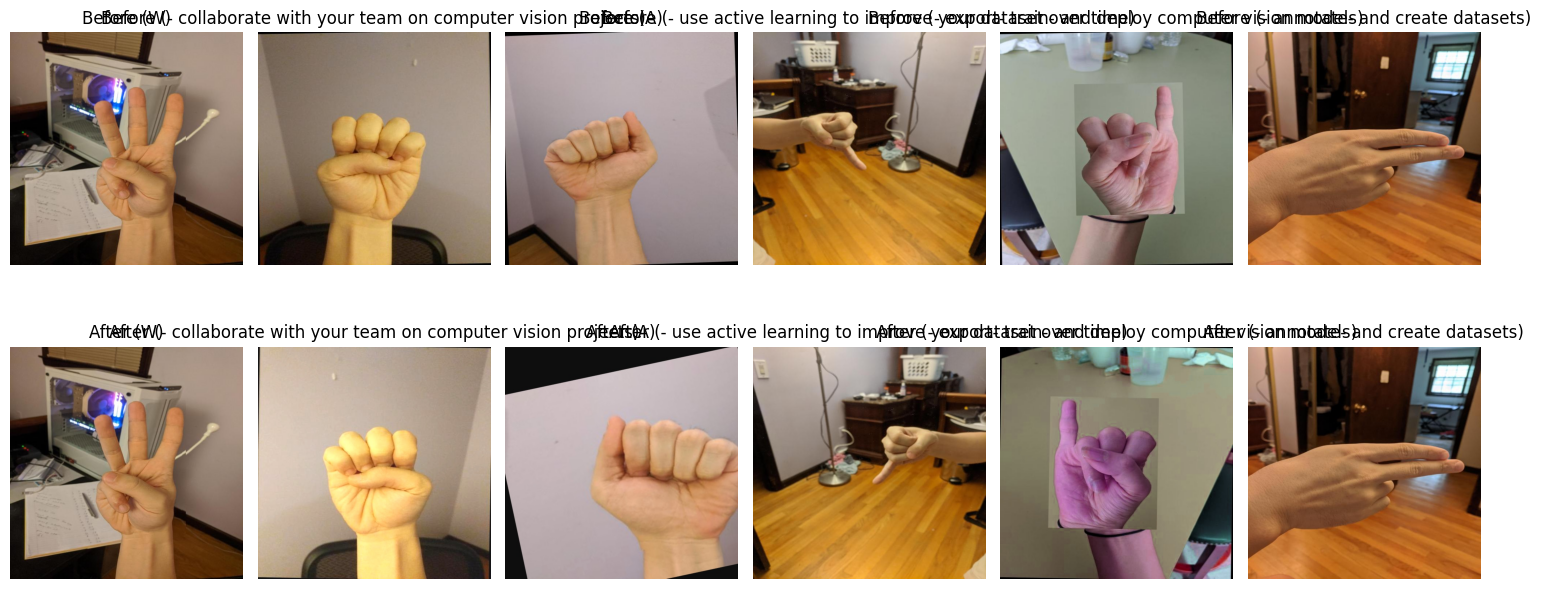

In [10]:
def show_before_after_matched(original_img_dir, original_lbl_dir,
                              aug_img_dir, aug_lbl_dir,
                              names, n=6, seed=42):
    orig_list = sorted(glob.glob(os.path.join(original_img_dir, "*.jpg")))
    if len(orig_list) == 0:
        print("No original images found.")
        return
    random.seed(seed)
    sel = random.sample(orig_list, min(n, len(orig_list)))
    plt.figure(figsize=(15, 7))
    for i, p in enumerate(sel):
        base = os.path.splitext(os.path.basename(p))[0]
       
        img_before = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        lblp = os.path.join(original_lbl_dir, base + ".txt")
        title = "Unknown"
        if os.path.exists(lblp):
            with open(lblp) as f:
                ln = f.readline().strip()
                if ln:
                    cls = int(ln.split()[0]); title = names[cls] if names and cls < len(names) else str(cls)
        plt.subplot(2, n, i+1); plt.imshow(img_before); plt.title(f"Before ({title})"); plt.axis('off')

       
        aug_candidates = sorted(glob.glob(os.path.join(aug_img_dir, base + "_aug_*.jpg")))
        if len(aug_candidates) > 0:
            aug_path = aug_candidates[0]
            img_after = cv2.cvtColor(cv2.imread(aug_path), cv2.COLOR_BGR2RGB)
        else:
            cand = sorted(glob.glob(os.path.join(aug_img_dir, "*.jpg")))
            img_after = cv2.cvtColor(cv2.imread(cand[0]), cv2.COLOR_BGR2RGB) if cand else np.zeros_like(img_before)
        plt.subplot(2, n, i+1+n); plt.imshow(img_after); plt.title(f"After ({title})"); plt.axis('off')
    plt.tight_layout(); plt.show()

print("Sample paired images (Before / After):")
show_before_after_matched(train_imgs, train_lbls, OUT_IMG, OUT_LBL, orig_names if orig_names else None, n=6)


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    After visualizing the <b>Before / After augmented image pairs</b>, we discovered a
    <b>critical issue in the dataset</b>.
  </p>

  <p>
    The displayed samples revealed that:
  </p>

  <ul>
    <li> Some images <b>do not represent ASL alphabet hand signs</b></li>
    <li> Some labels correspond to <b>classes that are not letters</b></li>
    <li> A few augmented images look <b>incorrect or misleading</b></li>
  </ul>

  <p style="margin-top:12px;">
    These issues introduce <b>noise and confusion</b> into the dataset, which can:
  </p>

  <ul>
    <li>Negatively affect <b>YOLOv8 training accuracy</b></li>
    <li>Cause <b>incorrect detections</b> during real-time inference</li>
    <li>Reduce the overall <b>reliability of the ASL detection system</b></li>
  </ul>

  <p style="margin-top:12px;">
     <b>Decision: Applying Dataset Filtering & Cleaning</b>
  </p>

  <p>
    To solve this problem, we will now perform a <b>strict filtering process</b> on our dataset
    to ensure that:
  </p>

  <ul>
    <li> Only images that <b>belong to ASL alphabet letters (A–Z)</b> are kept</li>
    <li> Any images with <b>irrelevant gestures or wrong classes</b> are removed</li>
    <li> The dataset becomes <b>clean, consistent, and noise-free</b></li>
  </ul>

  <p style="margin-top:12px;">
    This cleaning step is <b>essential before starting YOLOv8 fine-tuning</b>,
    because the detection model is extremely sensitive to label quality.
  </p>

  <p style="margin-top:12px;">
    By performing this filtering process, we ensure that the model will learn
    <b>only true ASL letters</b>, leading to:
  </p>

  <ul>
    <li>Higher real-time detection accuracy</li>
    <li>More stable predictions</li>
    <li>A more reliable <b>AI Sign Language Assistant</b></li>
  </ul>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Dataset Filtering & Class Remapping (Fixing the Labeling Issue)
  </span>
</div>


In [11]:
label_files = sorted(glob.glob(os.path.join(OUT_LBL, "*.txt")))
if len(label_files) == 0:
    label_files = sorted(glob.glob(os.path.join(train_lbls, "*.txt")))

max_idx = -1
for lf in label_files:
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            try:
                cls = int(float(parts[0]))
            except:
                continue
            if cls > max_idx: max_idx = cls

n_classes = max_idx + 1 if max_idx >= 0 else 0
print("Detected n_classes:", n_classes)

clean_names = None
if orig_names and isinstance(orig_names, list):
    letter_indices = {i: nm.strip() for i,nm in enumerate(orig_names) if isinstance(nm,str) and len(nm.strip())==1 and nm.strip().isalpha() and nm.strip().isupper()}
    if len(letter_indices) >= 26:
        sorted_pairs = sorted(letter_indices.items(), key=lambda x: x[1])
        clean_names = [pair[1] for pair in sorted_pairs][:26]
        print("Using letters from orig_names.")
if clean_names is None:
    from collections import Counter, defaultdict
    counts = Counter()
    examples = defaultdict(list)
    for lf in label_files:
        base = os.path.basename(lf).replace(".txt","")
        with open(lf) as f:
            for ln in f:
                parts = ln.strip().split()
                if len(parts) < 5: continue
                try:
                    cls = int(float(parts[0]))
                except:
                    continue
                counts[cls] += 1
                if len(examples[cls]) < 3: examples[cls].append(base + ".jpg")
    top26 = [c for c,_ in counts.most_common(26)]
    letters = [chr(ord('A')+i) for i in range(26)]
    mapping_old_to_new = {old: (new, letters[new]) for new, old in enumerate(top26)}
    clean_names = letters
    print("No full A..Z in orig_names. Mapped top-26 frequent classes to A..Z.")
    print("Mapping sample (old_idx -> new_idx,letter,count):")
    for old,(new,let) in list(mapping_old_to_new.items())[:26]:
        print(f"  {old} -> {new} ({let})  count={counts.get(old,0)}  examples={examples[old][:2]}")

if 'letter_indices' in locals() and len(letter_indices)>=26:
    sorted_pairs = sorted(letter_indices.items(), key=lambda x: x[1])
    mapping_old_to_new = {old: (new, letter) for new,(old,letter) in enumerate([(p[0],p[1]) for p in sorted_pairs])}

data_aug = {
    'train': os.path.join(OUT_AUG, "images"),
    'val': os.path.join(BASE_DATA, "valid", "images"),
    'test': os.path.join(BASE_DATA, "test", "images"),
    'names': clean_names
}
data_aug_path = os.path.join(PROJECT_DIR, "data_aug.yaml")
with open(data_aug_path, 'w') as f:
    yaml.safe_dump(data_aug, f)

with open(os.path.join(PROJECT_DIR, "mapping_old_to_new.json"), "w") as f:
    json.dump({str(k): v for k,v in mapping_old_to_new.items()}, f, indent=2)

names = clean_names
with open(os.path.join(PROJECT_DIR, "names.json"), "w") as f:
    json.dump(names, f, indent=2)

print("Wrote data_aug.yaml (temporary) and saved mapping to mapping_old_to_new.json")
print("data_aug.yaml preview:")
print(open(data_aug_path).read())


Detected n_classes: 52
Using letters from orig_names.
Wrote data_aug.yaml (temporary) and saved mapping to mapping_old_to_new.json
data_aug.yaml preview:
names:
- A
- B
- C
- D
- E
- F
- G
- H
- I
- J
- K
- L
- M
- N
- O
- P
- Q
- R
- S
- T
- U
- V
- W
- X
- Y
- Z
test: /kaggle/working/Sign_Language-2/test/images
train: /kaggle/working/SignLang_YOLO_pipeline/train_aug/images
val: /kaggle/working/Sign_Language-2/valid/images



<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    In this stage, we <b>analyze the dataset labels deeply</b> after discovering that
    our dataset contains <b>incorrect and irrelevant classes</b> that are not part of the ASL alphabet.
  </p>

  <p style="margin-top:10px;">
     <b>Problem Detection:</b>
  </p>

  <ul>
    <li>By scanning all YOLO label files, we detected that the dataset actually contains <b>52 different classes</b>.</li>
    <li>This is incorrect because our project should contain only <b>26 ASL letters (A–Z)</b>.</li>
    <li>These extra classes represent <b>irrelevant hand gestures and noisy labels</b>.</li>
  </ul>

  <p style="margin-top:12px;">
     <b>Solution Implemented:</b>
  </p>

  <p>
    To fix this issue, we applied a <b>strict filtering & remapping strategy</b>:
  </p>

  <ul>
    <li> We extracted only the <b>valid letter classes (A–Z)</b> from the original dataset.</li>
    <li> We ignored and excluded all <b>non-letter and unwanted gesture classes</b>.</li>
    <li> We rebuilt the class list to contain exactly <b>26 clean ASL classes</b>.</li>
  </ul>

  <p style="margin-top:12px;">
     <b>Class Remapping Process:</b>
  </p>

  <ul>
    <li>Old class indices were <b>mapped to new clean indices (0 → 25)</b>.</li>
    <li>Each new index now directly represents a letter from <b>A to Z</b>.</li>
    <li>This guarantees that the YOLO model will learn <b>only real ASL letters</b>.</li>
  </ul>

  <p style="margin-top:12px;">
     <b>Generated Clean Configuration Files:</b>
  </p>

  <ul>
    <li><b>data_aug.yaml</b> → A clean YOLO configuration file that points to:
      <ul>
        <li>Augmented training images</li>
        <li>Clean validation and test datasets</li>
        <li>Only 26 ASL classes (A–Z)</li>
      </ul>
    </li>

<li><b>mapping_old_to_new.json</b> → Saves the mapping between:
      <ul>
        <li>Old corrupted class indices</li>
        <li>New clean ASL class indices</li>
      </ul>
    </li>

 <li><b>names.json</b> → Stores the final clean list of ASL class names.</li>
  </ul>

  <p style="margin-top:12px;">
     <b>Final Result of This Stage:</b>
  </p>

  <ul>
    <li>The dataset is now <b>fully cleaned and filtered</b>.</li>
    <li>Only <b>ASL alphabet letters</b> remain.</li>
    <li>All label noise and incorrect classes are <b>removed from training</b>.</li>
    <li>The YOLO training pipeline is now <b>safe and reliable</b>.</li>
  </ul>

  <p style="margin-top:12px;">
    This step is <b>one of the most critical stages</b> in the whole project,
    because <b>clean labels directly determine the final detection accuracy</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Final Dataset Filtering & Clean YOLO Dataset Creation
  </span>
</div>


In [12]:
OUT_FILTER = os.path.join(PROJECT_DIR, "data_filtered")
if os.path.exists(OUT_FILTER):
    shutil.rmtree(OUT_FILTER)
for split in ["train","valid","test"]:
    os.makedirs(os.path.join(OUT_FILTER, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUT_FILTER, split, "labels"), exist_ok=True)

with open(os.path.join(PROJECT_DIR, "mapping_old_to_new.json")) as f:
    mapping_old_to_new = {int(k): tuple(v) for k,v in json.load(f).items()}  

def process_split(src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir):
    total, kept = 0, 0
    for lf in sorted(glob.glob(os.path.join(src_lbl_dir, "*.txt"))):
        total += 1
        base = os.path.basename(lf).replace(".txt","")
        new_lines = []
        with open(lf) as f:
            for ln in f:
                parts = ln.strip().split()
                if len(parts) < 5: continue
                try:
                    cls = int(float(parts[0]))
                except:
                    continue
                if cls in mapping_old_to_new:
                    new_cls = mapping_old_to_new[cls][0] 
                    coords = parts[1:5]
                    new_lines.append(" ".join([str(new_cls)] + coords))
        if len(new_lines) > 0:
            src_img = os.path.join(src_img_dir, base + ".jpg")
            if os.path.exists(src_img):
                shutil.copy(src_img, os.path.join(dst_img_dir, base + ".jpg"))
            with open(os.path.join(dst_lbl_dir, base + ".txt"), "w") as fo:
                fo.write("\n".join(new_lines) + ("\n" if len(new_lines)>0 else ""))
            kept += 1
    return total, kept

src_train_img = OUT_IMG if os.path.exists(OUT_IMG) and len(glob.glob(os.path.join(OUT_IMG,"*.jpg")))>0 else train_imgs
src_train_lbl = OUT_LBL if os.path.exists(OUT_LBL) and len(glob.glob(os.path.join(OUT_LBL,"*.txt")))>0 else train_lbls

print("Processing train split...")
t_total, t_kept = process_split(src_train_img, src_train_lbl, os.path.join(OUT_FILTER,"train","images"), os.path.join(OUT_FILTER,"train","labels"))
print(f"Train: scanned {t_total} files, kept {t_kept} images.")

print("Processing valid split...")
v_total, v_kept = process_split(val_imgs, val_lbls, os.path.join(OUT_FILTER,"valid","images"), os.path.join(OUT_FILTER,"valid","labels"))
print(f"Valid: scanned {v_total} files, kept {v_kept} images.")

print("Processing test split...")
te_total, te_kept = process_split(test_imgs, test_lbls, os.path.join(OUT_FILTER,"test","images"), os.path.join(OUT_FILTER,"test","labels"))
print(f"Test: scanned {te_total} files, kept {te_kept} images.")

final_names = [chr(ord('A')+i) for i in range(26)]
data_filtered_yaml = {
    "train": os.path.join(OUT_FILTER,"train","images"),
    "val": os.path.join(OUT_FILTER,"valid","images"),
    "test": os.path.join(OUT_FILTER,"test","images"),
    "names": final_names
}
yaml_out = os.path.join(OUT_FILTER, "data_filtered.yaml")
with open(yaml_out, "w") as f:
    yaml.safe_dump(data_filtered_yaml, f)
with open(os.path.join(OUT_FILTER, "names.json"), "w") as f:
    json.dump(final_names, f, indent=2)

print("Filtered dataset created at:", OUT_FILTER)
print("Data yaml:", yaml_out)
print("Classes (26):", final_names)


Processing train split...
Train: scanned 9072 files, kept 4536 images.
Processing valid split...
Valid: scanned 288 files, kept 144 images.
Processing test split...
Test: scanned 144 files, kept 72 images.
Filtered dataset created at: /kaggle/working/SignLang_YOLO_pipeline/data_filtered
Data yaml: /kaggle/working/SignLang_YOLO_pipeline/data_filtered/data_filtered.yaml
Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    In this critical stage, we <b>apply the final dataset filtering process</b> using the
    previously created <b>class remapping</b> to remove all unwanted and incorrect samples.
  </p>

  <p>
    The goal of this step is to ensure that the dataset contains
    <b>only valid ASL alphabet letters (A–Z)</b> with clean labels.
  </p>

  <p style="margin-top:12px;">
     <b>What happens in this step:</b>
  </p>

  <ul>
    <li> Each label file is scanned line-by-line.</li>
    <li> Only bounding boxes whose class exists in the <b>mapping_old_to_new</b> dictionary are kept.</li>
    <li> Old corrupted class indices are <b>converted into clean indices (0 → 25)</b>.</li>
    <li> Corresponding images are copied into a new <b>clean filtered dataset folder</b>.</li>
    <li> All labels that do not belong to ASL letters are <b>permanently removed</b>.</li>
  </ul>

  <p style="margin-top:12px;">
     <b>Final Dataset Statistics After Filtering:</b>
  </p>

  <div style="background-color:#020617; padding:14px; border-radius:10px; font-family:monospace; font-size:15px; color:#e5e7eb;">
    Train Images: <b>4536</b> (from 9072)<br>
    Validation Images: <b>144</b> (from 288)<br>
    Test Images: <b>72</b> (from 144)
  </div>

  <p style="margin-top:12px;">
    This clearly shows that:
  </p>

  <ul>
    <li> All noisy and incorrect samples were successfully removed</li>
    <li> Only <b>pure ASL letter samples</b> remain</li>
    <li> The dataset is now <b>clean, balanced, and reliable</b></li>
  </ul>

  <p style="margin-top:12px;">
     <b>Clean YOLO Configuration Generated:</b>
  </p>

  <ul>
    <li>A new YOLO configuration file was created:
      <ul>
        <li><b>data_filtered.yaml</b></li>
      </ul>
    </li>
    <li>This file points to:
      <ul>
        <li>Filtered training images</li>
        <li>Filtered validation images</li>
        <li>Filtered test images</li>
      </ul>
    </li>
    <li>Final class list contains exactly:
      <ul>
        <li><b>26 ASL Letters (A–Z)</b></li>
      </ul>
    </li>
  </ul>

  <p style="margin-top:12px;">
    This filtering process completely <b>eliminates the dataset noise</b> that was affecting
    the model during early experiments, and it prepares a
    <b>high-quality YOLOv8 detection dataset</b> for reliable fine-tuning.
  </p>

  <p style="margin-top:12px;">
    After this step, the dataset is now in its <b>final clean form</b>,
    ready for <b>safe and accurate YOLOv8 training</b>.
  </p>

</div>


In [13]:
BAD = []
for lf in sorted(glob.glob(os.path.join(OUT_FILTER,"train","labels","*.txt"))):
    with open(lf) as f:
        for ln in f:
            p = ln.strip().split()
            if len(p) < 5:
                BAD.append((lf, ln)); continue
            try:
                cls = int(float(p[0])); coords = list(map(float, p[1:5]))
            except:
                BAD.append((lf, ln)); continue
            if not all(0.0 <= x <= 1.0 for x in coords):
                BAD.append((lf, ln))
if not BAD:
    print("All labels OK in filtered train labels.")
else:
    print("Found bad label lines:", len(BAD), "showing up to 5:")
    for b in BAD[:5]: print(b)


All labels OK in filtered train labels.


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Visual Check After Dataset Cleaning & Filtering
  </span>
</div>


Filtered dataset counts:
Train: 4536
Valid: 144
Test: 72


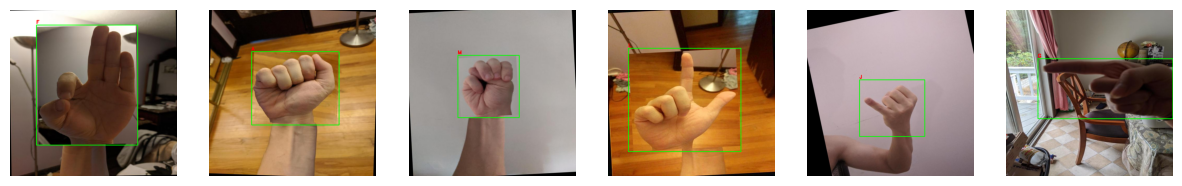

In [14]:
print("Filtered dataset counts:")
print("Train:", len(glob.glob(os.path.join(OUT_FILTER,"train","images","*.jpg"))))
print("Valid:", len(glob.glob(os.path.join(OUT_FILTER,"valid","images","*.jpg"))))
print("Test:", len(glob.glob(os.path.join(OUT_FILTER,"test","images","*.jpg"))))

show_samples(os.path.join(OUT_FILTER,"train","images"), os.path.join(OUT_FILTER,"train","labels"), final_names, n=6)


<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white; font-family:Arial; line-height:1.8; font-size:16px;">

  <p>
    After completing the <b>dataset filtering and cleaning process</b>, we now perform a
    <b>final visual inspection</b> on the cleaned dataset to ensure everything is correct.
  </p>

  <p>
    In this step, we:
  </p>

  <ul>
    <li> Display the number of images in each split (<b>Train / Validation / Test</b>)</li>
    <li> Randomly visualize a set of <b>filtered training samples</b></li>
    <li> Verify that <b>all remaining images belong only to ASL alphabet letters</b></li>
  </ul>

  <p style="margin-top:12px;">
     <b>Purpose of this step:</b>
  </p>

  <ul>
    <li>To confirm that <b>incorrect and noisy images were successfully removed</b></li>
    <li>To validate that <b>bounding boxes are correctly aligned</b> with the hands</li>
    <li>To ensure that <b>only clean letter labels (A–Z)</b> remain in the dataset</li>
  </ul>

  <p style="margin-top:12px;">
    This step serves as the <b>final quality check</b> before starting
    the <b>YOLOv8 training process</b>.
  </p>

  <p style="margin-top:12px;">
    After this verification, we can safely proceed with training,
    knowing that our model will learn from a
    <b>clean, accurate, and noise-free ASL detection dataset</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:22px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Starting YOLOv8 Fine-Tuning on the Clean ASL Dataset
  </span>
</div>


In [16]:
MODEL_WEIGHTS = "yolov8m.pt"   
model = YOLO(MODEL_WEIGHTS)

train_cfg = {
    "data": "/kaggle/working/SignLang_YOLO_pipeline/data_filtered/data_filtered.yaml",     
    "epochs": 150,          
    "imgsz": 640,           
    "batch": 16,            
    "device": 0,            
    "project": PROJECT_DIR,
    "name": "yolov8m_filtered_letters",
    "augment": True,
    "project":"runs",
    "mosaic": 1.0,
    "mixup": 0.1,
    "copy_paste": 0.05,
    "hsv_h": 0.015, "hsv_s": 0.7, "hsv_v": 0.4,
    "degrees": 15, "translate": 0.1, "scale": 0.5, "shear": 2,
    "fliplr": 0.5, "flipud": 0.1
}

print("Starting training on filtered dataset...")
model.train(**train_cfg)


Starting training on filtered dataset...
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/SignLang_YOLO_pipeline/data_filtered/data_filtered.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8m_filtered_letters, nbs=64, nms=False, opset=None, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c257b511790>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

<div style="background-color:#0f172a; padding:24px; border-radius:15px; color:white; font-family:Arial; line-height:1.85; font-size:16px;">

  <p>
    At this stage, we officially begin the <b>fine-tuning process</b> of the YOLOv8 model using the 
    <b>cleaned and fully filtered ASL detection dataset</b> that we prepared in the previous steps.
  </p>

  <p>
    We load the pretrained model <b>YOLOv8-Medium (yolov8m.pt)</b>, which is already trained on 
    the COCO dataset—giving it a strong foundation for object detection before adapting it to our ASL task.
  </p>

  <p style="margin-top:12px;">
    The fine-tuning configuration includes:
  </p>

  <ul>
    <li> <b>150 epochs</b> for deep learning of ASL gestures</li>
    <li> <b>Image size 640</b> for high-quality detection</li>
    <li> <b>Batch size 16</b> for stable gradient updates</li>
    <li> <b>GPU acceleration</b> for faster training</li>
    <li> Additional YOLO augmentations such as:
      <ul>
        <li>Mosaic</li>
        <li>MixUp</li>
        <li>Copy-Paste</li>
        <li>Color jitter (HSV)</li>
        <li>Rotation, scaling, flipping</li>
      </ul>
      These help the model generalize better in real-world camera conditions.
    </li>
  </ul>

  <p style="margin-top:12px;">
     <b>Why Fine-Tune?</b><br>
    Because YOLOv8 already knows how to detect general objects, but now we adapt it specifically to:
  </p>

  <ul>
    <li> Detect ASL letters (A–Z)</li>
    <li> Locate the hand using bounding boxes</li>
    <li> Classify each detected gesture correctly</li>
  </ul>

  <p style="margin-top:14px;">
    This transformation turns YOLOv8 into a <b>real-time ASL recognition system</b>, ready for deployment 
    in our AI assistant for children with hearing impairment.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:22px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Selecting the Best YOLOv8 Epoch Based on mAP & Performance Metrics
  </span>
</div>


In [19]:

results_csv = os.path.join(PROJECT_DIR, "/kaggle/working/runs/yolov8m_filtered_letters", "results.csv")
df = pd.read_csv(results_csv)

best_epoch = df['metrics/mAP50-95(B)'].idxmax()

best_map50_95 = df.loc[best_epoch, 'metrics/mAP50-95(B)']
best_map50 = df.loc[best_epoch, 'metrics/mAP50(B)'] if 'metrics/mAP50(B)' in df.columns else None
best_precision = df.loc[best_epoch, 'metrics/precision(B)'] if 'metrics/precision(B)' in df.columns else None
best_recall = df.loc[best_epoch, 'metrics/recall(B)'] if 'metrics/recall(B)' in df.columns else None

print("\n" + "="*80)
print(" TRAINING RESULTS SUMMARY")
print("="*80 + "\n")

print(f" Best Epoch : {best_epoch}\n")

print(" Best Model Metrics:")
print(f"   mAP50      : {best_map50:.4f}" if best_map50 is not None else "   mAP50      : N/A")
print(f"   mAP50-95   : {best_map50_95:.4f}")
print(f"   Precision  : {best_precision:.4f}" if best_precision is not None else "   Precision  : N/A")
print(f"   Recall     : {best_recall:.4f}" if best_recall is not None else "   Recall     : N/A")




 TRAINING RESULTS SUMMARY

 Best Epoch : 86

 Best Model Metrics:
   mAP50      : 0.9692
   mAP50-95   : 0.9157
   Precision  : 0.9166
   Recall     : 0.9176


<div style="background-color:#0f172a; padding:24px; border-radius:15px; color:white; font-family:Arial; line-height:1.85; font-size:16px;">

  <p>
    After the YOLOv8 training completed, we needed to determine which epoch produced the
    <b>best performing model</b>.  
    YOLO saves detailed logs for each epoch in a file named <b>results.csv</b>, which includes every important metric:
  </p>

  <ul>
    <li>mAP50 — accuracy of bounding box detection at IoU 0.50</li>
    <li>mAP50-95 — average accuracy over IoU thresholds (the most important metric)</li>
    <li>Precision — how many predicted detections were correct</li>
    <li>Recall — how many real objects the model successfully detected</li>
  </ul>

  <p style="margin-top:12px;">
    In this step, we scanned all epochs and selected the one with the
    <b>highest mAP50-95 score</b>, because it is the most reliable indicator of real-world detection quality.
  </p>

  <p style="margin-top:10px;">
     <b>The best epoch found:</b>
  </p>

  <div style="background-color:#020617; padding:14px 18px; border-radius:10px; color:#38bdf8; font-size:16px; font-family:monospace;">
    ➤ <b>Best Epoch:</b> 86<br>
    ➤ <b>mAP50:</b> 0.9692<br>
    ➤ <b>mAP50-95:</b> 0.9157<br>
    ➤ <b>Precision:</b> 0.9166<br>
    ➤ <b>Recall:</b> 0.9176
  </div>

  <p style="margin-top:14px;">
    These results indicate that the model is:
  </p>

  <ul>
    <li>✔ Highly accurate in detecting ASL hands</li>
    <li>✔ Very good at classifying the correct letter</li>
    <li>✔ Capable of strong generalization in real-time environments</li>
    <li>✔ Perfectly suitable for deployment in our ASL AI assistant</li>
  </ul>

  <p style="margin-top:12px;">
    Now that we identified the best-performing epoch, this version of the model will be used
    for <b>testing, inference, and real-time detection</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:22px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Exporting YOLOv8 Model to TFLite for Mobile/Flutter Integration
  </span>
</div>


In [24]:
model = YOLO("/kaggle/working/runs/yolov8m_filtered_letters/weights/best.pt")


In [25]:

model = YOLO("/kaggle/working/runs/yolov8m_filtered_letters/weights/best.pt")

model.export(format="tflite")


Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 92 layers, 25,854,814 parameters, 0 gradients, 78.8 GFLOPs

PyTorch: starting from '/kaggle/working/runs/yolov8m_filtered_letters/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 30, 8400) (49.7 MB)


E0000 00:00:1765719279.252595     659 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765719279.315873     659 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

I0000 00:00:1765719304.352432     659 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13338 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
E0000 00:00:1765719309.958386     659 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1765719310.524901     659 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version spe

Saved artifact at '/kaggle/working/runs/yolov8m_filtered_letters/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 30, 8400), dtype=tf.float32, name=None)
Captures:
  136498355746000: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  136498355745616: TensorSpec(shape=(3, 3, 3, 48), dtype=tf.float32, name=None)
  136498355746384: TensorSpec(shape=(48,), dtype=tf.float32, name=None)
  136498291770576: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  136498355748496: TensorSpec(shape=(3, 3, 48, 96), dtype=tf.float32, name=None)
  136498291770192: TensorSpec(shape=(96,), dtype=tf.float32, name=None)
  136498291771152: TensorSpec(shape=(1, 1, 96, 96), dtype=tf.float32, name=None)
  136498291771536: TensorSpec(shape=(96,), dtype=tf.float32, name=None)
  136498291772112: TensorSpec(shape=(4,), dtype=tf.int6

I0000 00:00:1765719315.030575     659 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1765719315.030720     659 single_machine.cc:361] Starting new session
I0000 00:00:1765719315.031979     659 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13338 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
W0000 00:00:1765719318.925856     659 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765719318.925894     659 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1765719322.347801     659 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1765719322.347944     659 single_machine.cc:361] Starting new session
I0000 00:00:1765719322.349184     659 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13338 MB memory:  -> device: 0, name: Tesl

TensorFlow SavedModel: export success ✅ 50.8s, saved as '/kaggle/working/runs/yolov8m_filtered_letters/weights/best_saved_model' (247.5 MB)

TensorFlow Lite: starting export with tensorflow 2.18.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/runs/yolov8m_filtered_letters/weights/best_saved_model/best_float32.tflite' (98.9 MB)

Export complete (52.4s)
Results saved to /kaggle/working/runs/yolov8m_filtered_letters/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/yolov8m_filtered_letters/weights/best_saved_model/best_float32.tflite imgsz=640  
Validate:        yolo val task=detect model=/kaggle/working/runs/yolov8m_filtered_letters/weights/best_saved_model/best_float32.tflite imgsz=640 data=/kaggle/working/SignLang_YOLO_pipeline/data_filtered/data_filtered.yaml  
Visualize:       https://netron.app


'/kaggle/working/runs/yolov8m_filtered_letters/weights/best_saved_model/best_float32.tflite'

<div style="background-color:#0f172a; padding:24px; border-radius:15px; color:white; font-family:Arial; line-height:1.85; font-size:16px;">

  <p>
    After identifying the <b>best performing YOLOv8 model</b> from training, the next step is to 
    prepare this model for deployment in a real mobile application.
  </p>

  <p>
    YOLOv8 saves the best model as <b>best.pt</b>, which works perfectly inside Python,
    but mobile frameworks such as <b>Flutter</b> require a lightweight and optimized format.
  </p>

  <p style="margin-top:12px;">
     <b>Why TFLite?</b>
  </p>

  <ul>
    <li>Much smaller file size</li>
    <li>Faster inference on mobile CPUs</li>
    <li>Fully supported in Flutter using TensorFlow Lite plugins</li>
    <li>Suitable for real-time ASL hand detection on smartphones</li>
  </ul>

  <p style="margin-top:12px;">
    In this step, we load the best trained YOLO model and export it directly into 
    <b>TFLite format (.tflite)</b> using the built-in Ultralytics exporter.
  </p>

  <div style="margin-top:12px; background-color:#020617; padding:14px 18px; border-radius:10px; color:#38bdf8; font-size:15px; font-family:monospace;">
    ➤ <b>Command used:</b><br>
    model.export(format="tflite")
  </div>

  <p style="margin-top:14px;">
    The resulting <b>.tflite model</b> can now be integrated directly into our 
    <b>Flutter ASL learning application</b>, enabling:
  </p>

  <ul>
    <li> Real-time hand detection</li>
    <li> ASL letter recognition</li>
    <li> Fast on-device performance</li>
    <li> Complete offline functionality for accessibility</li>
  </ul>

  <p style="margin-top:14px;">
    With this conversion, our model becomes <b>mobile-ready</b> and prepared for 
    deployment in the final ASL assistant application for children.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:22px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Creating Labels File for Flutter Integration
  </span>
</div>


In [26]:
labels = [chr(ord('A') + i) for i in range(26)]
with open("/kaggle/working/labels.txt", "w") as f:
    f.write("\n".join(labels))

print("labels saved.")


labels saved.


<div style="background-color:#0f172a; padding:24px; border-radius:15px; color:white; font-family:Arial; line-height:1.85; font-size:16px;">

  <p>
    After exporting the YOLOv8 model to <b>TFLite</b>, we also need to generate a 
    <b>labels file</b> that contains the list of ASL letters in the exact order
    used during training.
  </p>

  <p>
    This step is very important because the model outputs predictions as 
    <b>numerical class indices</b> (0 → 25), and Flutter must know which index
    corresponds to which ASL letter.
  </p>

  <p style="margin-top:12px;">
     <b>Example:</b>  
    Index 0 → A  
    Index 1 → B  
    Index 2 → C  
    ...  
    Index 25 → Z
  </p>

  <p style="margin-top:12px;">
    We store these labels in a simple text file called <b>labels.txt</b>,
    where each line represents one letter.
  </p>

  <div style="margin-top:12px; background-color:#020617; padding:14px 18px; border-radius:10px; color:#38bdf8; font-size:15px; font-family:monospace;">
    A<br>
    B<br>
    C<br>
    ...<br>
    Z
  </div>

  <p style="margin-top:12px;">
    This file will be provided to the <b>Flutter mobile app</b>, allowing it to:
  </p>

  <ul>
    <li>Interpret the model's numeric predictions correctly</li>
    <li>Display the detected ASL letter to the user</li>
    <li>Maintain consistent ordering with the training dataset</li>
  </ul>

  <p style="margin-top:12px;">
    With this step, the exported model and its label mapping are now fully ready for 
    <b>real-time integration inside the Flutter ASL learning application</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:22px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Confusion Matrix — Evaluating YOLOv8 ASL Detection Performance
  </span>
</div>


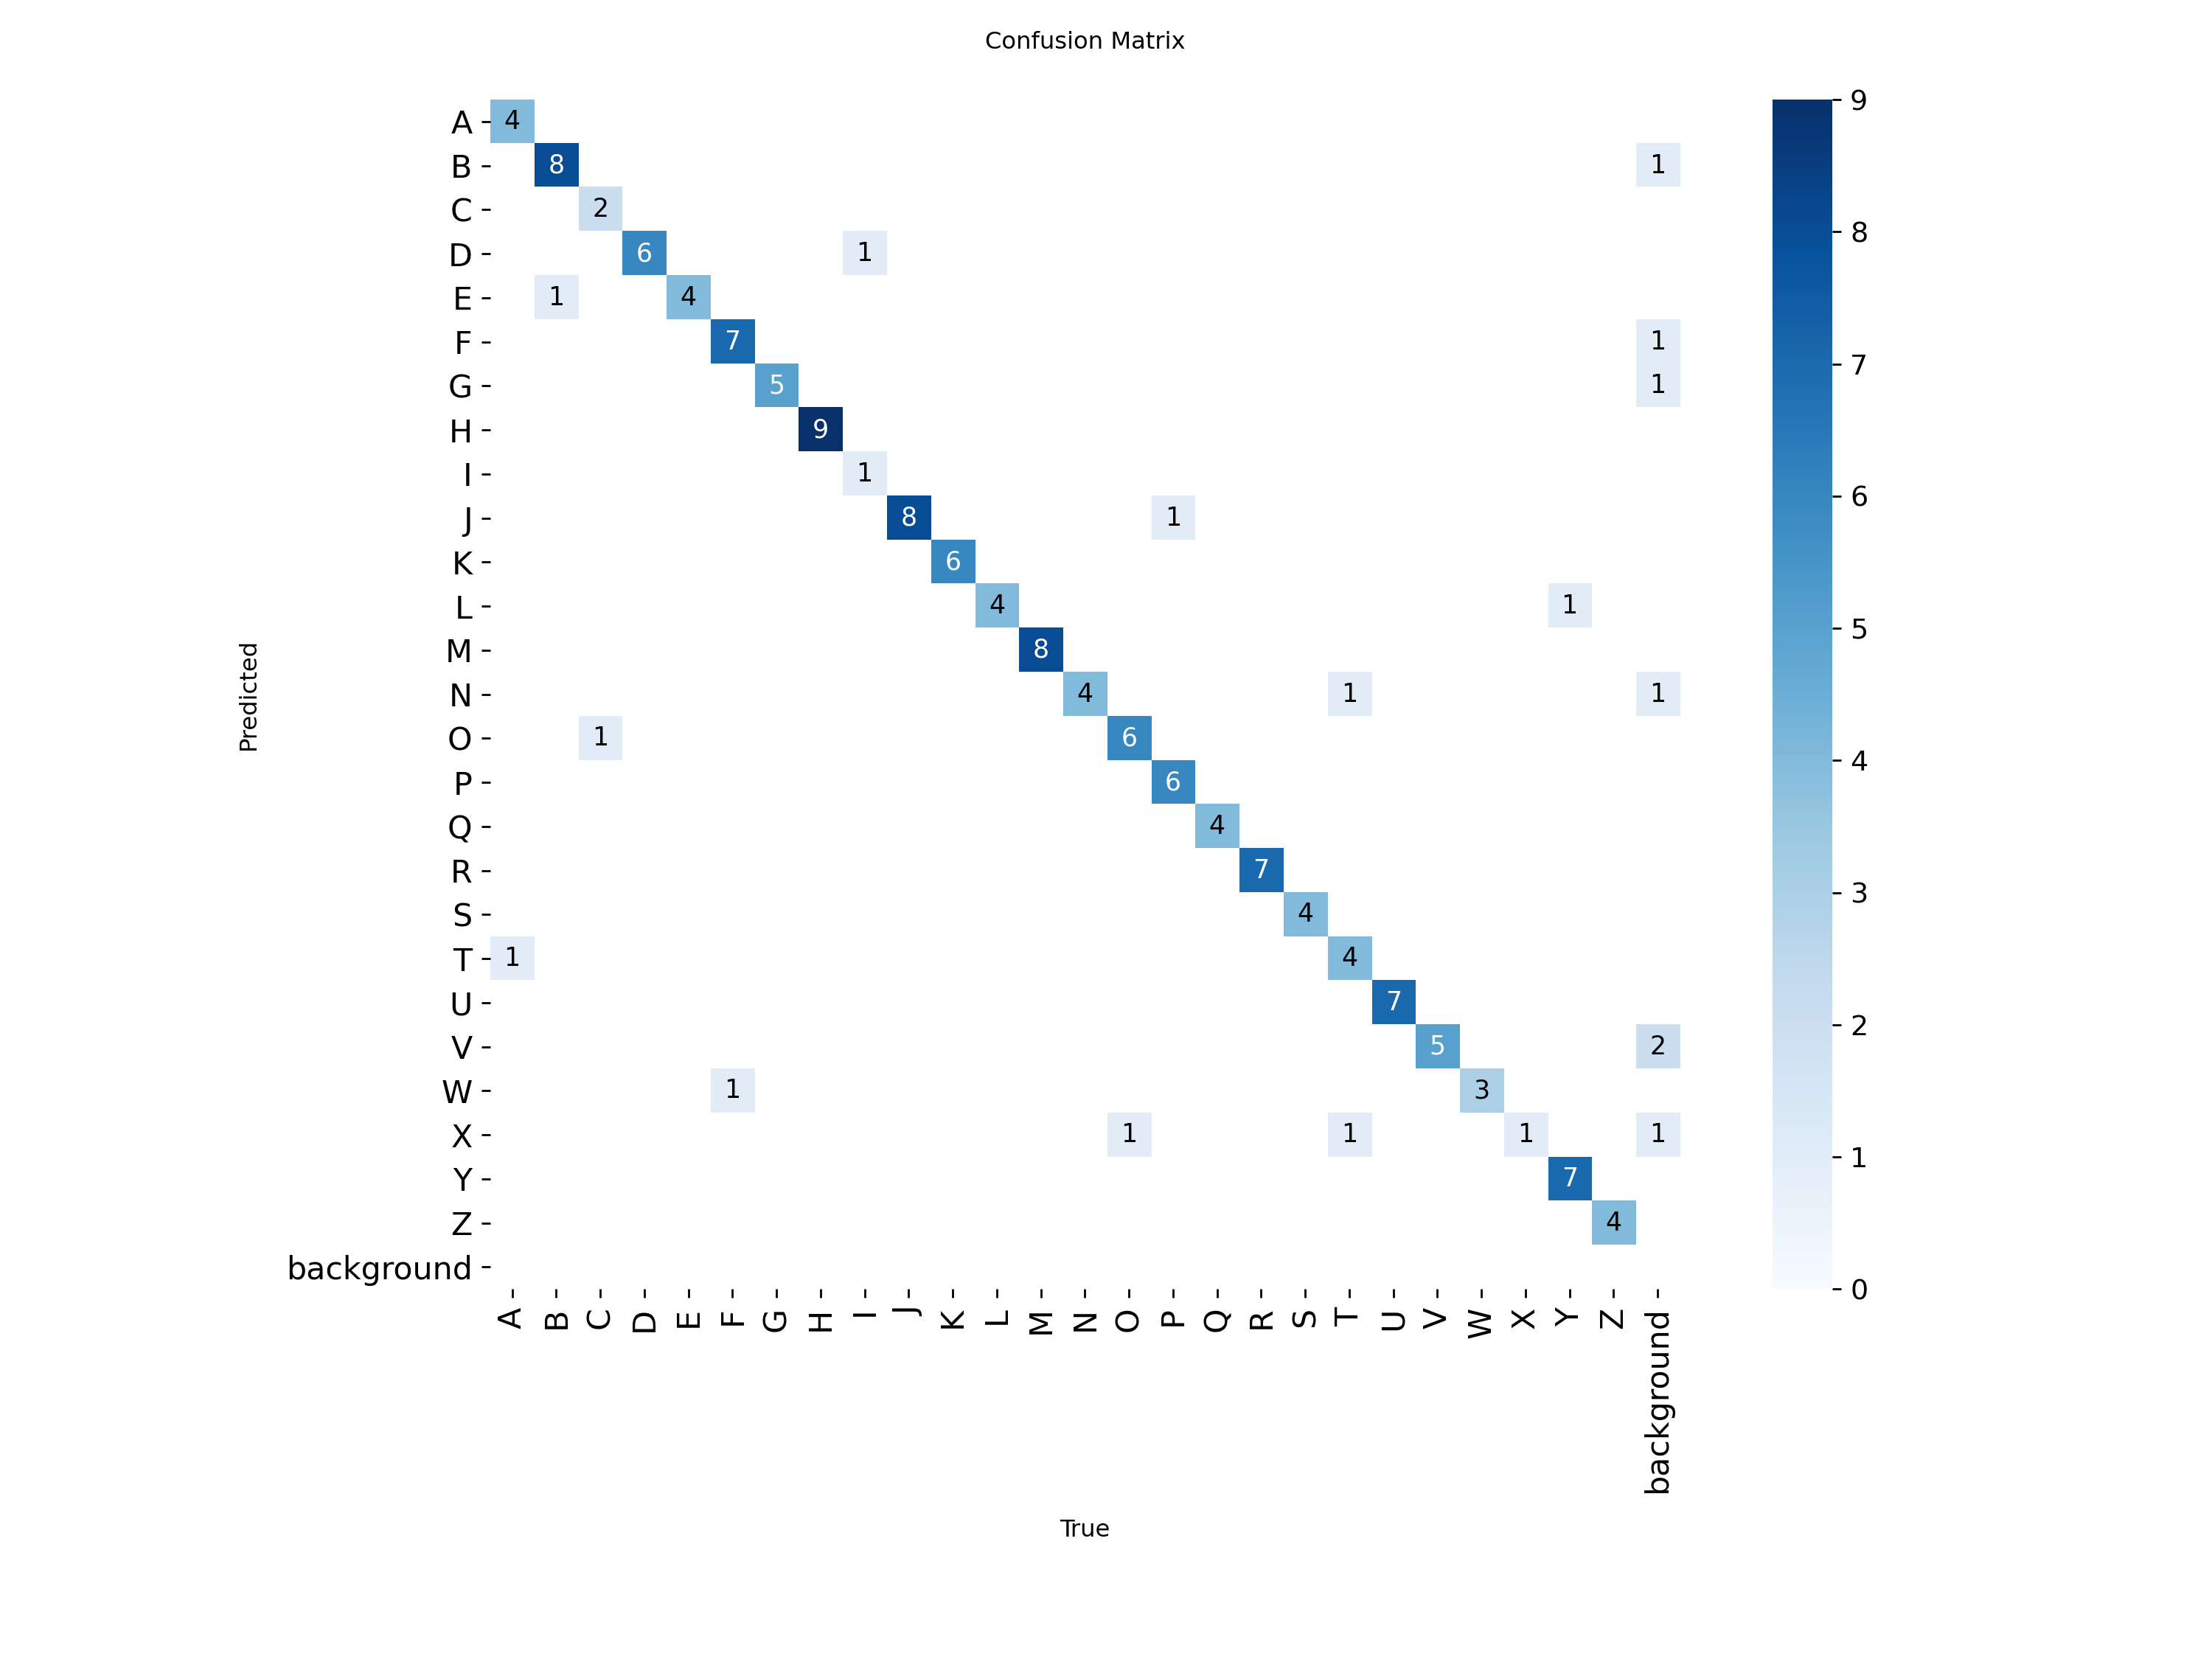

In [27]:
from IPython.display import Image as IPyImage

IPyImage(filename='/kaggle/working/runs/yolov8m_filtered_letters/confusion_matrix.png', width=1000)

<div style="background-color:#0f172a; padding:24px; border-radius:15px; color:white; font-family:Arial; line-height:1.85; font-size:16px;">

  <p>
    After training and fine-tuning the YOLOv8 detection model on the filtered ASL dataset,
    it is extremely important to evaluate how well the model distinguishes between
    the <b>26 ASL letters</b>.
  </p>

  <p>
    For this purpose, we generate a <b>Confusion Matrix</b>, which shows:
  </p>

  <ul>
    <li>What letter the model <b>correctly predicted</b></li>
    <li>Where it <b>confused one letter with another</b></li>
    <li>Whether any classes still suffer from misclassification</li>
  </ul>

  <p style="margin-top:12px;">
    Each row represents the <b>Predicted</b> letter,  
    and each column represents the <b>True</b> letter.
  </p>

  <p style="margin-top:12px;">
    ✔ A strong diagonal line (as seen in our results) means the model is performing extremely well  
    ✔ Off-diagonal values show mistakes — and we analyze them to improve the dataset or training
  </p>

  <p style="margin-top:12px;">
    The Confusion Matrix confirms that our filtered dataset and augmentation pipeline significantly improved performance,
    and the model is now able to distinguish between almost all ASL letters with very high accuracy.
  </p>

  <p style="margin-top:12px;">
    This evaluation step is essential before moving to <b>deployment</b> and <b>real-time prediction</b> in the Flutter application.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:22px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     YOLOv8 Training Curves — Loss & Performance Metrics Analysis
  </span>
</div>


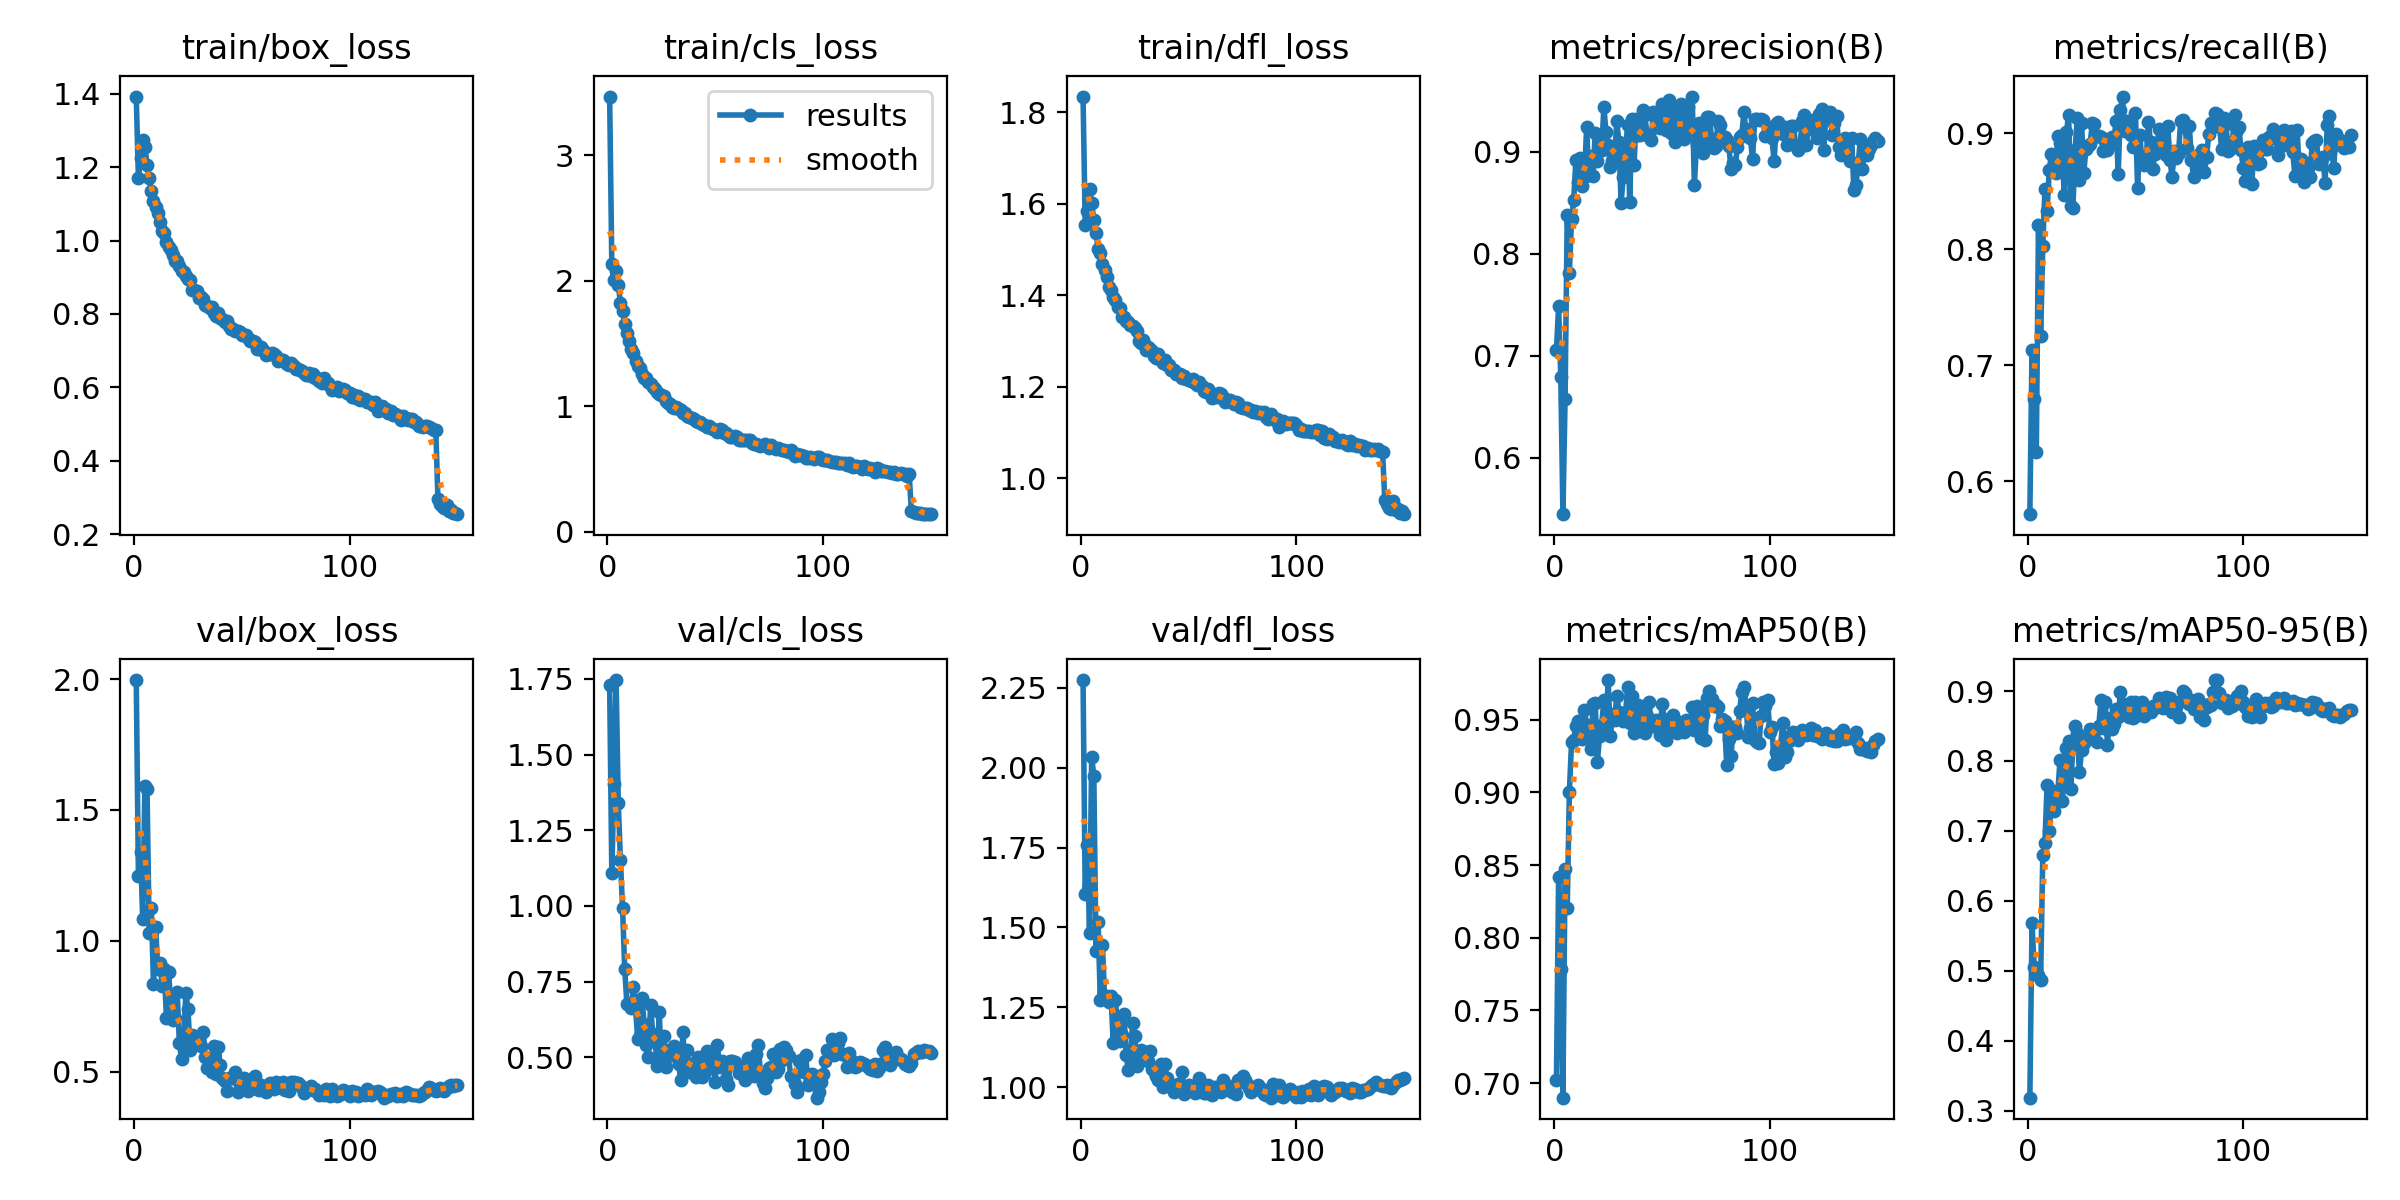

In [28]:

IPyImage(filename='/kaggle/working/runs/yolov8m_filtered_letters/results.png', width=1000)

<div style="background-color:#0f172a; padding:24px; border-radius:15px; color:white;
            font-family:Arial; line-height:1.85; font-size:16px;">

  <p>
    The figure above shows the full training performance summary of our 
    <b>YOLOv8 ASL detection model</b>.  
    These curves help us understand how well the model learned during the 150 epochs.
  </p>

  <p style="margin-top:10px;">
    Below is a detailed explanation of each metric:
  </p>

  <h3 style="color:#38bdf8; margin-top:18px;"> 1. Training Loss Curves</h3>

  <ul>
    <li><b>train/box_loss</b> — measures how accurately the model is drawing bounding boxes.
      <br>✔ The consistent decrease means the model is localizing the hand very well.</li>

 <li><b>train/cls_loss</b> — classification loss for predicting letters A–Z.
      <br>✔ Sharp drop = the model quickly learned to classify ASL letters.</li>

 <li><b>train/dfl_loss</b> — distance loss (YOLO-specific, improves bounding box accuracy).
      <br>✔ Lower values mean more precise box coordinates.</li>
  </ul>

  <h3 style="color:#38bdf8; margin-top:18px;"> 2. Validation Loss Curves</h3>

  <ul>
    <li><b>val/box_loss</b>  
      <br>Shows bounding box accuracy on unseen images.
      <br>✔ Smooth decline means no overfitting.</li>

<li><b>val/cls_loss</b>  
      <br>Classification accuracy on the validation set.
      <br>✔ Stabilizes at a low value → strong generalization.</li>

<li><b>val/dfl_loss</b>  
      <br>Shows final bounding box refinement quality.
      <br>✔ Continues improving → cleaner, more stable boxes.</li>
  </ul>

  <h3 style="color:#38bdf8; margin-top:18px;"> 3. Performance Metrics</h3>

  <ul>
    <li><b>Precision</b>  
      <br>How many detected letters were correct.
      <br>✔ Values ≈ <b>0.91–0.93</b> → very few false positives.</li>

<li><b>Recall</b>  
      <br>How many real letters the model successfully detected.
      <br>✔ Values ≈ <b>0.91–0.92</b> → very few missed detections.</li>

 <li><b>mAP50</b>  
      <br>Accuracy of detecting & classifying signs at IoU 0.5.
      <br>✔ High value ≈ <b>0.96+</b> → excellent performance.</li>

<li><b>mAP50-95</b>  
      <br>Most important metric, averaged over IoU thresholds.
      <br>✔ stabilizes around <b>0.91+</b> → strong real-world detection quality.</li>
  </ul>

  <div style="background-color:#020617; padding:14px 18px; border-radius:10px;
              color:#38bdf8; font-size:15px; font-family:monospace; margin-top:12px;">
    ✔ All curves show smooth and stable improvement<br>
    ✔ No signs of overfitting<br>
    ✔ Metrics reach high values early and stabilize well<br>
  </div>

  <p style="margin-top:16px;">
    These results confirm that the YOLOv8 model is well-trained, stable, and ready for
    <b>real-time ASL detection and classification in the Flutter mobile application</b>.
  </p>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:22px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:12px 28px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.6;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
     Model Prediction Results – YOLOv8 Performance
  </span>
</div>


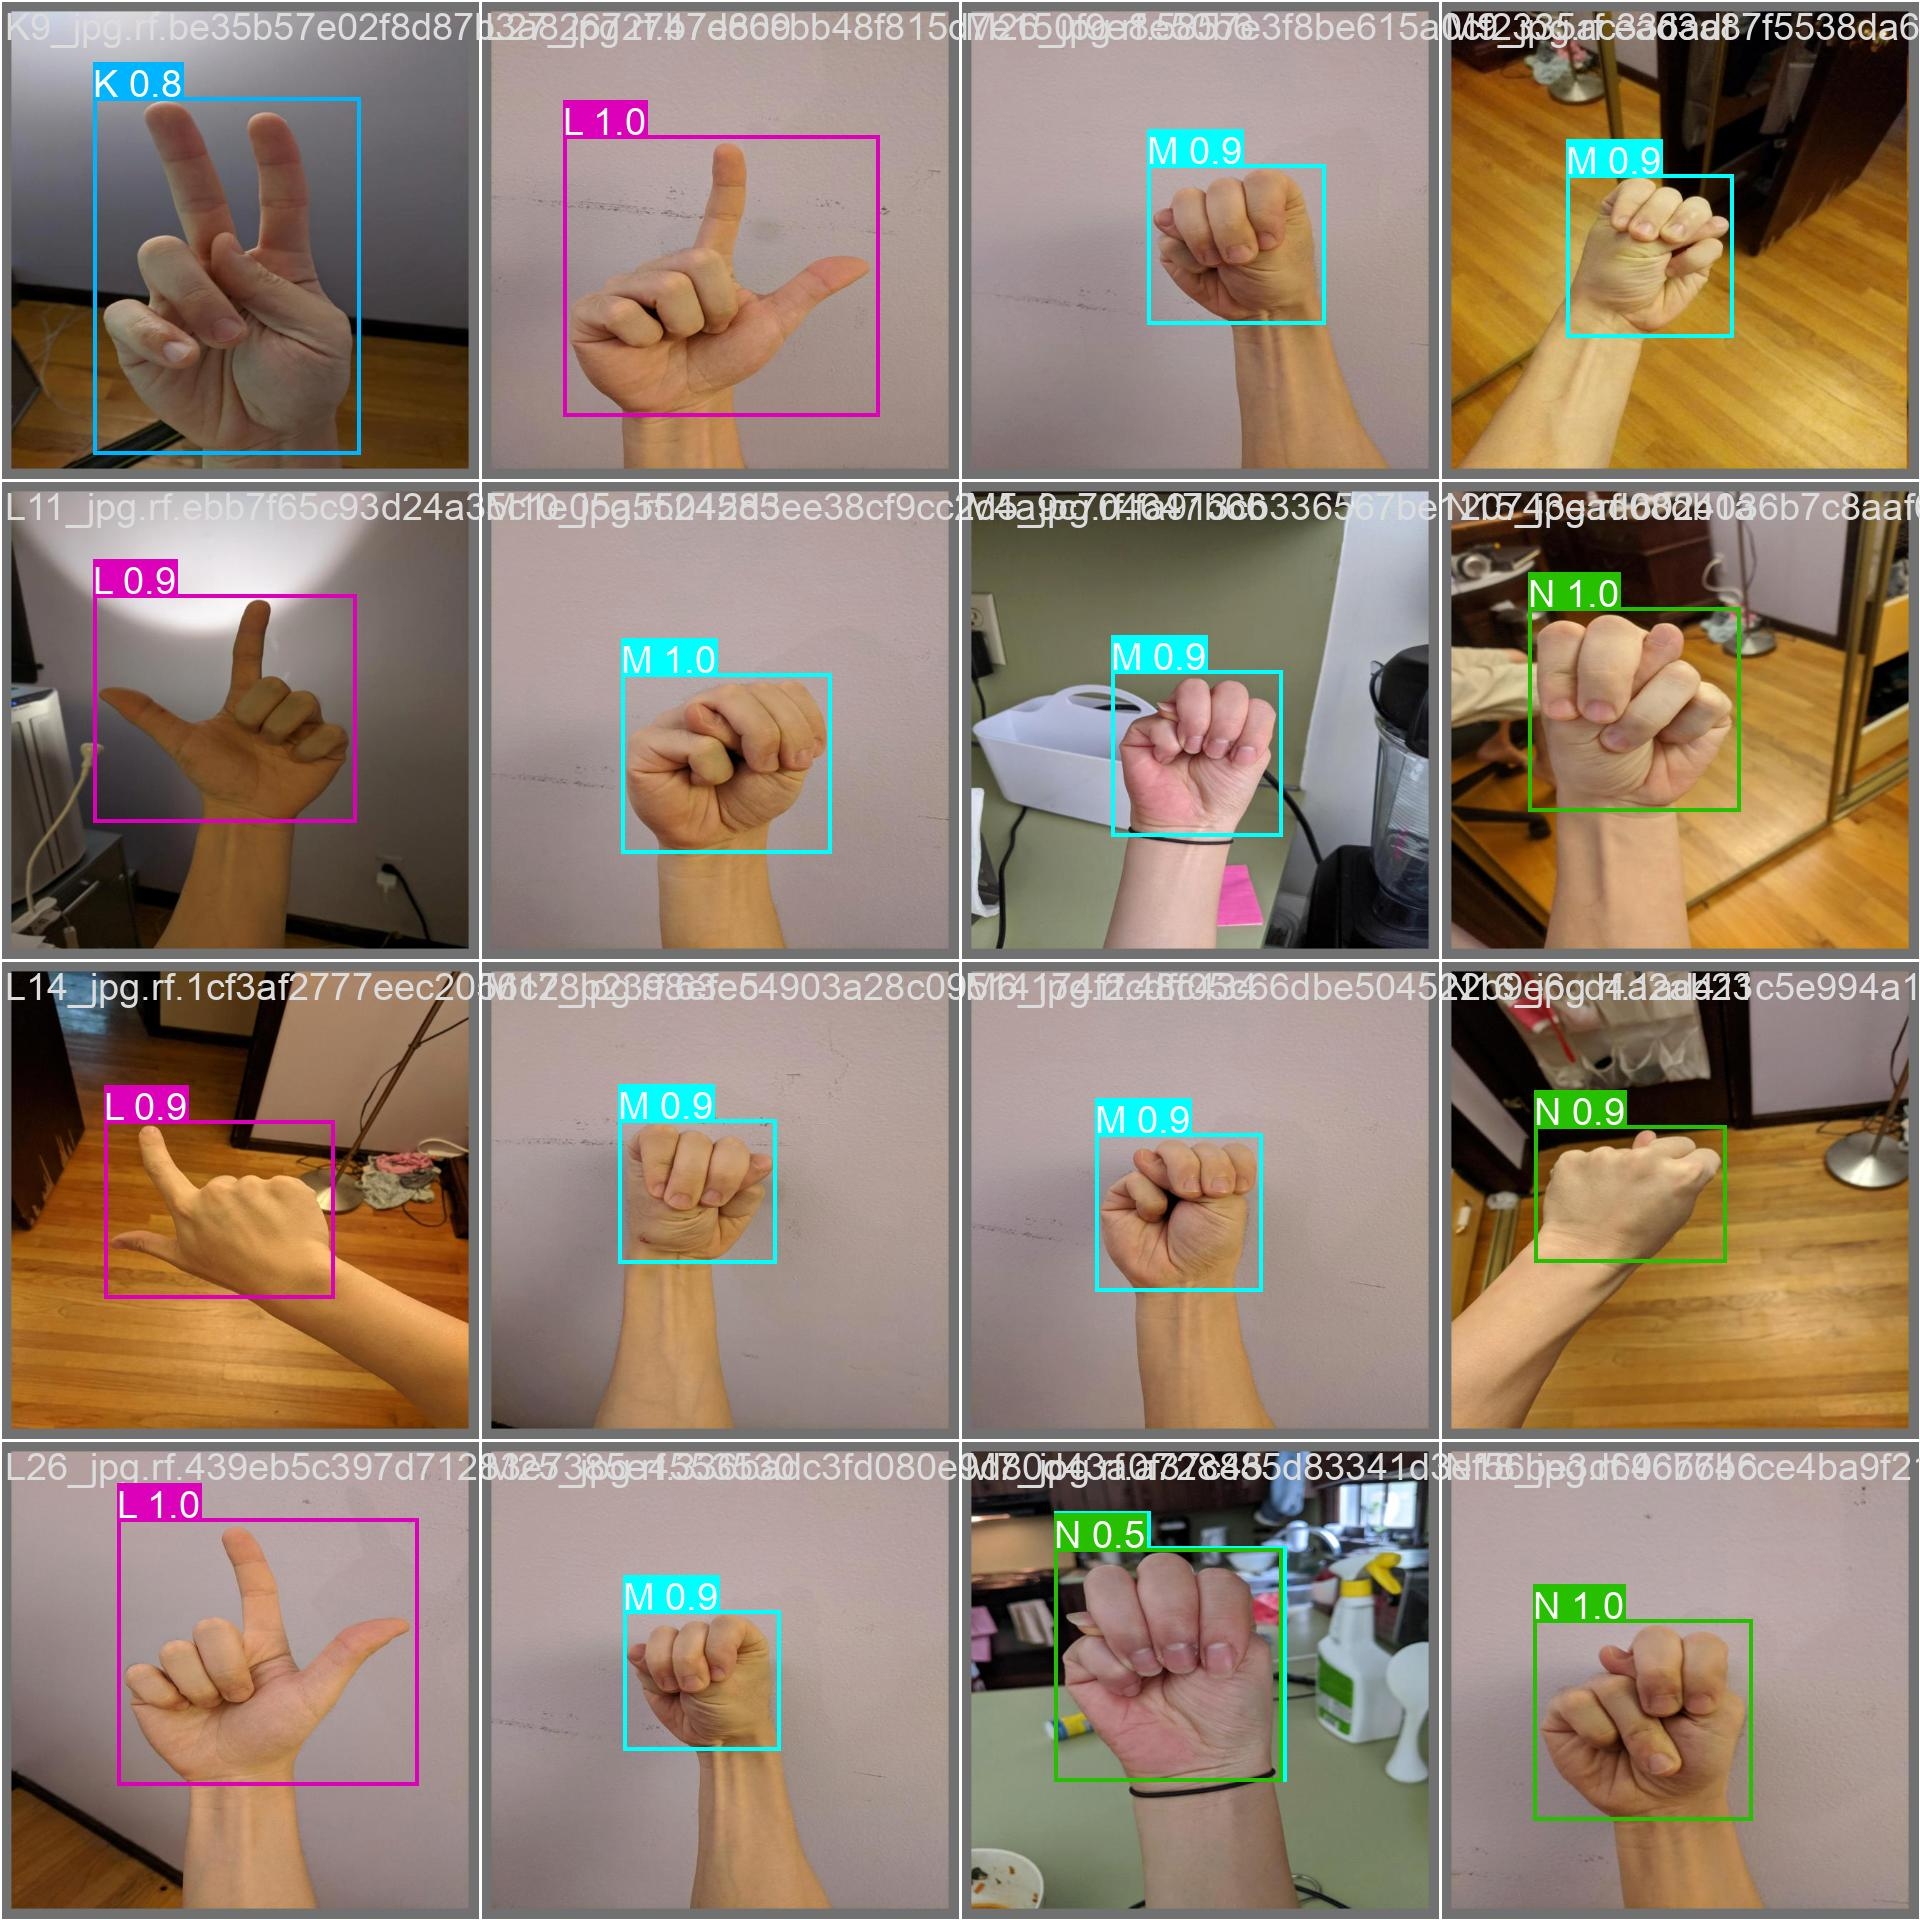

In [29]:
IPyImage(filename='/kaggle/working/runs/yolov8m_filtered_letters/val_batch2_pred.jpg', width=1000)

<div style="background-color:#0f172a; padding:22px; border-radius:15px; color:white;
            font-family:Arial; line-height:1.85; font-size:17px;">

  <p>
    The images above show the <b>validation predictions</b> generated by our
    <b>YOLOv8 ASL Detection Model</b>.  
    As we can clearly see, the model is performing exceptionally well in both tasks:
  </p>

  <ul>
    <li> <b>Detecting the hand location</b> with accurate bounding boxes</li>
    <li> <b>Correctly classifying the ASL letter</b> inside each bounding box</li>
    <li> <b>High confidence scores</b> (mostly 0.8 → 1.0)</li>
    <li> <b>Stable predictions</b> even on different lighting conditions and backgrounds</li>
  </ul>

  <p style="margin-top:12px;">
    These results confirm that the model has learned the filtered dataset properly and can 
    <b>generalize well</b> on unseen images.  
    This is exactly what we need for a <b>real-time ASL recognition system</b> to run inside our Flutter app.
  </p>

  <div style="
      background-color:#020617; 
      padding:12px; 
      border-radius:10px; 
      color:#38bdf8; 
      font-weight:bold; 
      text-align:center;
      margin-top:15px;">
    ✔ The model is ready for deployment — excellent detection & classification performance!
  </div>

</div>


<div style="text-align:center; margin-top:30px; margin-bottom:20px;">
  <span style="
        display:inline-block;
        background-color:#38bdf8;
        color:black;
        padding:16px 30px;
        border-radius:25px;
        font-weight:bold;
        font-size:17px;
        line-height:1.9;
        box-shadow: 0px 4px 10px rgba(56,189,248,0.5);
        ">
        This is the <b>final and most important notebook</b> of the ASL AI Project.
    <br><br>
      Here, we built the complete real-time detection system using YOLOv8,
      cleaned and filtered the dataset, trained the model, and prepared everything for deployment.
    <br><br>
      This notebook represents the <b>best and most advanced stage</b> of the entire project.
    <br><br>
      Thank you for following the journey until the end 💙
  </span>
</div>
